### BiLSTM-CRF for NER

- Dataset:  word_bio_flat.csv  (resume_id | token | tag)
- Tags:     BIO scheme over 10 entity types
- Model:    Embedding -> BiLSTM -> Linear -> CRF


Import

In [1]:
import numpy as np
import pickle
import json
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import classification_report
from seqeval.metrics import classification_report as seq_classification_report, f1_score as seq_f1, precision_score as seq_precision, recall_score as seq_recall
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.12.0+cpu


Data Loading

In [2]:
DATA_DIR = Path('../../datasets/processed_data')

# Load numpy arrays
X_tokens = np.load(DATA_DIR / 'X_tokens.npy')           # (N, 256)
X_chars  = np.load(DATA_DIR / 'X_chars.npy')            # (N, 256, 20)
Y_labels = np.load(DATA_DIR / 'Y_labels.npy')           # (N, 256)
masks    = np.load(DATA_DIR / 'masks.npy')               # (N, 256)
emb_mat  = np.load(DATA_DIR / 'embedding_matrix.npy')   # (vocab, 300)

# Load vocabularies
with open(DATA_DIR / 'vocabs.pkl', 'rb') as f:
    vocabs = pickle.load(f)

token2id      = vocabs['token2id']
id2token      = vocabs['id2token']
label2id      = vocabs['label2id']
id2label      = vocabs['id2label']
char2id       = vocabs['char2id']
PAD_ID        = vocabs['PAD_ID']
UNK_ID        = vocabs['UNK_ID']
PAD_LABEL_ID  = vocabs['PAD_LABEL_ID']
EMBED_DIM     = vocabs['EMBED_DIM']       # 300
MAX_LEN       = vocabs['MAX_LEN_LSTM']    # 256
Entity_labels = vocabs['Entity_labels']

VOCAB_SIZE  = len(token2id)
CHAR_SIZE   = len(char2id)
NUM_LABELS  = len(label2id)
MAX_CHAR    = X_chars.shape[2]            # 20

print(f'Resumes        : {X_tokens.shape[0]}')
print(f'Max seq length : {MAX_LEN}')
print(f'Token vocab    : {VOCAB_SIZE:,}')
print(f'Char vocab     : {CHAR_SIZE}')
print(f'Num labels     : {NUM_LABELS}')
print(f'Embed dim      : {EMBED_DIM}')
print(f'Label map      :')
for lbl, idx in label2id.items():
    print(f'  {idx:>3}  {lbl}')

Resumes        : 220
Max seq length : 256
Token vocab    : 4,638
Char vocab     : 62
Num labels     : 22
Embed dim      : 300
Label map      :
    0  <PAD_LABEL>
    1  O
    2  B-Name
    3  I-Name
    4  B-Designation
    5  I-Designation
    6  B-Companies worked at
    7  I-Companies worked at
    8  B-Location
    9  I-Location
   10  B-Email Address
   11  I-Email Address
   12  B-College Name
   13  I-College Name
   14  B-Degree
   15  I-Degree
   16  B-Graduation Year
   17  I-Graduation Year
   18  B-Skills
   19  I-Skills
   20  B-Years of Experience
   21  I-Years of Experience


Dataset setting (fetch from split dir)

In [3]:
class ResumeNERDataset(Dataset):
    """
    PyTorch Dataset for resume NER.
    Each item: (token_ids, char_ids, label_ids, mask)
    """
    def __init__(self, X_tokens, X_chars, Y_labels, masks):
        self.X_tokens = torch.tensor(X_tokens, dtype=torch.long)
        self.X_chars  = torch.tensor(X_chars,  dtype=torch.long)
        self.Y_labels = torch.tensor(Y_labels, dtype=torch.long)
        self.masks    = torch.tensor(masks,    dtype=torch.bool)

    def __len__(self):
        return len(self.X_tokens)

    def __getitem__(self, idx):
        return (
            self.X_tokens[idx],
            self.X_chars[idx],
            self.Y_labels[idx],
            self.masks[idx],
        )



# ── Load pre-defined split indices ───────────────────────────────────
with open('../../datasets/split_data/split_indices.json', 'r') as f:
    split_idx = json.load(f)

idx_train = split_idx['idx_train']
idx_val   = split_idx['idx_val']
idx_test  = split_idx['idx_test']

dataset = ResumeNERDataset(X_tokens, X_chars, Y_labels, masks)

from torch.utils.data import Subset
train_ds = Subset(dataset, idx_train)
val_ds   = Subset(dataset, idx_val)
test_ds  = Subset(dataset, idx_test)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')

Train: 154 | Val: 33 | Test: 33


Define CRF Model

In [4]:
class CRF(nn.Module):
    """
    Conditional Random Field layer.

    Learns transition scores between BIO labels so that
    invalid tag sequences (e.g. I-Skill after O) are penalised
    during training and cannot appear in Viterbi decoding.

    Parameters
    ----------
    num_tags     : number of output labels (including PAD)
    pad_tag_id   : label id for <PAD_LABEL> — excluded from transitions
    """

    def __init__(self, num_tags: int, pad_tag_id: int = 0):
        super().__init__()
        self.num_tags   = num_tags
        self.pad_tag_id = pad_tag_id

        # Transition matrix:  transitions[i, j] = score of going from tag j -> tag i
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))

        # Start / end pseudo-scores
        self.start_transitions = nn.Parameter(torch.randn(num_tags))
        self.end_transitions   = nn.Parameter(torch.randn(num_tags))

        self._init_transitions()

    def _init_transitions(self):
        # Forbid transitioning to/from PAD
        nn.init.constant_(self.transitions[:, self.pad_tag_id], -10000.)
        nn.init.constant_(self.transitions[self.pad_tag_id, :], -10000.)
        nn.init.constant_(self.start_transitions[self.pad_tag_id], -10000.)
        nn.init.constant_(self.end_transitions[self.pad_tag_id],   -10000.)

    # ------------------------------------------------------------------
    # Forward score  (log-partition function via forward algorithm)
    # ------------------------------------------------------------------
    def _forward_alg(self, emissions: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        emissions : (batch, seq_len, num_tags)
        mask      : (batch, seq_len)  bool — True for real tokens
        Returns   : (batch,)  log-partition
        """
        batch, seq_len, num_tags = emissions.shape
        # Alpha at t=0
        alpha = self.start_transitions + emissions[:, 0]   # (batch, num_tags)

        for t in range(1, seq_len):
            # (batch, num_tags, 1) + (num_tags, num_tags) + (batch, 1, num_tags)
            score = alpha.unsqueeze(2) + self.transitions + emissions[:, t].unsqueeze(1)
            score = torch.logsumexp(score, dim=1)          # (batch, num_tags)
            # Only update for real (non-padding) positions
            alpha = torch.where(mask[:, t].unsqueeze(1), score, alpha)

        alpha = alpha + self.end_transitions
        return torch.logsumexp(alpha, dim=1)               # (batch,)

    # ------------------------------------------------------------------
    # Gold score  (sum of emission + transition scores along true path)
    # ------------------------------------------------------------------
    def _score_sentence(self, emissions: torch.Tensor,
                         tags: torch.Tensor,
                         mask: torch.Tensor) -> torch.Tensor:
        batch, seq_len, _ = emissions.shape

        # Start score
        score = self.start_transitions[tags[:, 0]] + emissions[:, 0].gather(1, tags[:, 0:1]).squeeze(1)

        for t in range(1, seq_len):
            active = mask[:, t]                             # (batch,)
            trans  = self.transitions[tags[:, t], tags[:, t - 1]]   # (batch,)
            emit   = emissions[:, t].gather(1, tags[:, t:t+1]).squeeze(1)
            score  = score + torch.where(active, trans + emit, torch.zeros_like(score))

        # End score — use last real tag
        seq_ends = mask.long().sum(dim=1) - 1              # index of last real token
        last_tags = tags.gather(1, seq_ends.unsqueeze(1)).squeeze(1)
        score = score + self.end_transitions[last_tags]
        return score                                        # (batch,)

    # ------------------------------------------------------------------
    # Viterbi decode
    # ------------------------------------------------------------------
    def decode(self, emissions: torch.Tensor, mask: torch.Tensor) -> list[list[int]]:
        """
        emissions : (batch, seq_len, num_tags)
        mask      : (batch, seq_len)  bool
        Returns   : list of lists, each containing predicted tag ids for real tokens only
        """
        batch, seq_len, num_tags = emissions.shape
        viterbi  = self.start_transitions + emissions[:, 0]    # (batch, num_tags)
        backptr  = []

        for t in range(1, seq_len):
            score = viterbi.unsqueeze(2) + self.transitions     # (batch, num_tags, num_tags)
            best_scores, best_tags = score.max(dim=1)           # (batch, num_tags)
            backptr.append(best_tags)
            cur = best_scores + emissions[:, t]
            viterbi = torch.where(mask[:, t].unsqueeze(1), cur, viterbi)

        viterbi = viterbi + self.end_transitions
        _, best_last = viterbi.max(dim=1)                       # (batch,)

        # Backtrack
        best_paths = []
        seq_lens   = mask.long().sum(dim=1).tolist()
        best_last  = best_last.tolist()

        for b in range(batch):
            best_tag = best_last[b]
            path = [best_tag]
            for bp in reversed(backptr[:seq_lens[b] - 1]):
                best_tag = bp[b, best_tag].item()
                path.append(best_tag)
            path.reverse()
            best_paths.append(path)

        return best_paths

    # ------------------------------------------------------------------
    # Negative log-likelihood loss
    # ------------------------------------------------------------------
    def forward(self, emissions: torch.Tensor,
                tags: torch.Tensor,
                mask: torch.Tensor) -> torch.Tensor:
        """
        Returns mean NLL loss over the batch.
        """
        log_likelihood = (
            self._score_sentence(emissions, tags, mask)
            - self._forward_alg(emissions, mask)
        )
        return -log_likelihood.mean()


print('CRF layer defined.')

CRF layer defined.


CharCNN definition

In [5]:
class CharCNN(nn.Module):
    """
    Character-level CNN that produces a fixed-size embedding per token.

    Input  : (batch * seq_len, max_char)  — character IDs per token
    Output : (batch * seq_len, out_channels)  — char embedding per token

    Architecture
    ------------
    Char embedding → Conv1d (kernel 3) → ReLU → MaxPool over time → dropout
    """

    def __init__(self, char_vocab_size: int, char_embed_dim: int = 30,
                 out_channels: int = 50, kernel_size: int = 3,
                 dropout: float = 0.5, pad_idx: int = 0):
        super().__init__()
        self.char_embed = nn.Embedding(char_vocab_size, char_embed_dim, padding_idx=pad_idx)
        self.conv       = nn.Conv1d(char_embed_dim, out_channels, kernel_size, padding=kernel_size // 2)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (batch * seq_len, max_char)
        """
        emb = self.char_embed(x)            # (B*L, max_char, char_dim)
        emb = self.dropout(emb)
        emb = emb.permute(0, 2, 1)         # (B*L, char_dim, max_char)  for Conv1d
        conv_out = torch.relu(self.conv(emb))   # (B*L, out_channels, max_char)
        pooled   = conv_out.max(dim=2).values   # (B*L, out_channels)  global max-pool
        return pooled


print('CharCNN defined.')

CharCNN defined.


BiLSTM CRF Definition

In [6]:
class BiLSTM_CRF(nn.Module):
    """
    BiLSTM-CRF for sequence labelling.

    Pipeline
    --------
    1. Token IDs  → pre-trained FastText word embeddings (optionally fine-tuned)
    2. Char IDs   → CharCNN → char embeddings
    3. Concat word + char embeddings
    4. Dropout
    5. Bidirectional LSTM  (optionally stacked)
    6. Linear projection → emission scores  (batch, seq_len, num_tags)
    7. CRF  (training: NLL loss;  inference: Viterbi decode)

    Parameters
    ----------
    embedding_matrix : np.ndarray  (vocab_size, embed_dim)
    char_vocab_size  : int
    num_tags         : int
    pad_tag_id       : int   — PAD label id
    hidden_dim       : int   — LSTM hidden size per direction
    num_layers       : int   — stacked LSTM layers
    char_embed_dim   : int
    char_out_channels: int   — CNN output channels per token
    dropout          : float
    freeze_embeddings: bool  — freeze FastText weights
    """

    def __init__(
        self,
        embedding_matrix: np.ndarray,
        char_vocab_size : int,
        num_tags        : int,
        pad_token_id    : int = 0,
        pad_tag_id      : int = 0,
        hidden_dim      : int = 256,
        num_layers      : int = 2,
        char_embed_dim  : int = 30,
        char_out_channels: int = 50,
        kernel_size     : int = 3,
        dropout         : float = 0.5,
        freeze_embeddings: bool = False,
    ):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        # ── Word embeddings (FastText pre-trained) ──────────────────────
        self.word_embed = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=freeze_embeddings,
            padding_idx=pad_token_id,
        )

        # ── Character CNN ───────────────────────────────────────────────
        self.char_cnn = CharCNN(
            char_vocab_size = char_vocab_size,
            char_embed_dim  = char_embed_dim,
            out_channels    = char_out_channels,
            kernel_size     = kernel_size,
            dropout         = dropout,
        )

        lstm_input_dim = embed_dim + char_out_channels

        # ── Bi-LSTM ──────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size    = lstm_input_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)

        # ── Emission projection ──────────────────────────────────────────
        self.fc = nn.Linear(hidden_dim * 2, num_tags)

        # ── CRF ───────────────────────────────────────────────────────────
        self.crf = CRF(num_tags, pad_tag_id=pad_tag_id)

    # ------------------------------------------------------------------
    def _get_emissions(self, token_ids: torch.Tensor,
                        char_ids: torch.Tensor) -> torch.Tensor:
        batch, seq_len, max_char = char_ids.shape

        # Word embeddings
        word_emb = self.word_embed(token_ids)          # (B, L, embed_dim)
        word_emb = self.dropout(word_emb)

        # Char embeddings via CNN
        char_flat = char_ids.view(batch * seq_len, max_char)   # (B*L, max_char)
        char_emb  = self.char_cnn(char_flat)                   # (B*L, char_out)
        char_emb  = char_emb.view(batch, seq_len, -1)          # (B, L, char_out)

        # Concatenate
        combined = torch.cat([word_emb, char_emb], dim=2)      # (B, L, lstm_in)

        # BiLSTM
        lstm_out, _ = self.lstm(combined)                       # (B, L, 2*hidden)
        lstm_out    = self.layer_norm(lstm_out)
        lstm_out    = self.dropout(lstm_out)

        # Emission scores
        emissions = self.fc(lstm_out)                           # (B, L, num_tags)
        return emissions

    # ------------------------------------------------------------------
    def forward(self, token_ids, char_ids, tags, mask):
        """
        Training step — returns CRF NLL loss.
        """
        emissions = self._get_emissions(token_ids, char_ids)
        loss      = self.crf(emissions, tags, mask)
        return loss

    def predict(self, token_ids, char_ids, mask):
        """
        Inference — returns list of predicted tag-id sequences (real tokens only).
        """
        emissions = self._get_emissions(token_ids, char_ids)
        return self.crf.decode(emissions, mask)


print('BiLSTM-CRF model defined.')

BiLSTM-CRF model defined.


Initial model instantiation

In [7]:
model = BiLSTM_CRF(
    embedding_matrix  = emb_mat,
    char_vocab_size   = CHAR_SIZE,
    num_tags          = NUM_LABELS,
    pad_token_id      = PAD_ID,
    pad_tag_id        = PAD_LABEL_ID,
    hidden_dim        = 256,
    num_layers        = 2,
    char_embed_dim    = 30,
    char_out_channels = 50,
    kernel_size       = 3,
    dropout           = 0.5,
    freeze_embeddings = False,   # fine-tune: set False
).to(DEVICE)

# Count parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTrainable params : {trainable:,}')
print(f'Total params     : {total:,}')

BiLSTM_CRF(
  (word_embed): Embedding(4638, 300, padding_idx=0)
  (char_cnn): CharCNN(
    (char_embed): Embedding(62, 30, padding_idx=0)
    (conv): Conv1d(30, 50, kernel_size=(3,), stride=(1,), padding=(1,))
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (lstm): LSTM(350, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
  (fc): Linear(in_features=512, out_features=22, bias=True)
  (crf): CRF()
)

Trainable params : 4,232,792
Total params     : 4,232,792


Optimizer and Scheduler

In [8]:
LR         = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS  = 30
PATIENCE    = 5      # early stopping

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

print(f'Optimizer : AdamW  lr={LR}  wd={WEIGHT_DECAY}')
print(f'Scheduler : ReduceLROnPlateau  factor=0.5  patience=2')
print(f'Max epochs: {NUM_EPOCHS}  |  Early stopping patience: {PATIENCE}')

Optimizer : AdamW  lr=0.001  wd=0.0001
Scheduler : ReduceLROnPlateau  factor=0.5  patience=2
Max epochs: 30  |  Early stopping patience: 5


Train and eval epoch

In [9]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for token_ids, char_ids, labels, mask in loader:
        token_ids = token_ids.to(device)
        char_ids  = char_ids.to(device)
        labels    = labels.to(device)
        mask      = mask.to(device)

        optimizer.zero_grad()
        loss = model(token_ids, char_ids, labels, mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    for token_ids, char_ids, labels, mask in loader:
        token_ids = token_ids.to(device)
        char_ids  = char_ids.to(device)
        labels    = labels.to(device)
        mask      = mask.to(device)
        loss = model(token_ids, char_ids, labels, mask)
        total_loss += loss.item()
    return total_loss / len(loader)


# ── Training loop ────────────────────────────────────────────────────
history       = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_cnt  = 0
CKPT_PATH     = 'model_result/bilstm_crf_lstm.pt'

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss   = eval_epoch(model,  val_loader,   DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        patience_cnt  = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_cnt += 1

    mark = ' *' if improved else ''
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  '
          f'train={train_loss:.4f}  val={val_loss:.4f}{mark}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest val loss: {best_val_loss:.4f}  (checkpoint: {CKPT_PATH})')

Epoch   1/30  train=328.3870  val=120.9691 *
Epoch   2/30  train=184.8305  val=118.8665 *
Epoch   3/30  train=174.6499  val=105.4953 *
Epoch   4/30  train=150.2267  val=102.4332 *
Epoch   5/30  train=135.4324  val=88.8633 *
Epoch   6/30  train=121.0177  val=83.1694 *
Epoch   7/30  train=108.5285  val=77.0917 *
Epoch   8/30  train=94.1883  val=65.8054 *
Epoch   9/30  train=88.2445  val=61.5461 *
Epoch  10/30  train=73.1657  val=60.8786 *
Epoch  11/30  train=65.3398  val=60.4308 *
Epoch  12/30  train=59.6485  val=53.6118 *
Epoch  13/30  train=50.0164  val=53.4113 *
Epoch  14/30  train=44.4658  val=53.8738
Epoch  15/30  train=41.1831  val=54.9198
Epoch  16/30  train=41.6452  val=47.0988 *
Epoch  17/30  train=33.0066  val=48.1494
Epoch  18/30  train=31.2466  val=51.9657
Epoch  19/30  train=30.2083  val=45.9082 *
Epoch  20/30  train=27.0297  val=48.5674
Epoch  21/30  train=20.5892  val=47.1668
Epoch  22/30  train=17.9379  val=46.9221
Epoch  23/30  train=16.0790  val=46.1897
Epoch  24/30  tr

Hyperparams search space

In [10]:
import random, itertools


# ── Random Search hyperparameter space ───────────────────────────────
PARAM_DISTRIBUTIONS = {
    'hidden_dim'        : [128, 256, 512],
    'num_layers'        : [1, 2],
    'char_embed_dim'    : [25, 30, 50],
    'char_out_channels' : [30, 50, 75, 100],
    'kernel_size'       : [3, 5],
    'dropout'           : [0.2, 0.3, 0.4, 0.5, 0.6],
    'freeze_embeddings' : [True, False],
    'lr'                : [5e-4, 1e-3, 2e-3, 3e-3],
    'weight_decay'      : [1e-5, 1e-4, 5e-4, 1e-3],
    'batch_size'        : [16, 32, 64],
}

N_TRIALS      = 15    # increase for a more thorough search
SEARCH_EPOCHS = 15    # shorter budget per trial
SEARCH_PAT    = 3     # early-stop patience during search

def sample_params():
    return {k: random.choice(v) for k, v in PARAM_DISTRIBUTIONS.items()}

print(f'Search space size (combinatorial): '
      f'{sum(len(v) for v in PARAM_DISTRIBUTIONS.values())} discrete options')
print(f'Will sample {N_TRIALS} random configs, each up to {SEARCH_EPOCHS} epochs')

Search space size (combinatorial): 32 discrete options
Will sample 15 random configs, each up to 15 epochs


run trial for finetune

In [11]:
def run_trial(params: dict, trial_id: int) -> dict:
    """
    Build, train, and evaluate one hyperparameter configuration.
    Returns a result dict with the params and best val loss.
    """
    print(f'\n── Trial {trial_id+1}/{N_TRIALS} ──────────────────────────')
    print('  ' + '  '.join(f'{k}={v}' for k, v in params.items()))

    # ── DataLoaders (batch size may change per trial) ─────────────────
    bs = params['batch_size']
    t_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    v_loader = DataLoader(val_ds,   batch_size=bs, shuffle=False)

    # ── Model ─────────────────────────────────────────────────────────
    m = BiLSTM_CRF(
        embedding_matrix   = emb_mat,
        char_vocab_size    = CHAR_SIZE,
        num_tags           = NUM_LABELS,
        pad_token_id       = PAD_ID,
        pad_tag_id         = PAD_LABEL_ID,
        hidden_dim         = params['hidden_dim'],
        num_layers         = params['num_layers'],
        char_embed_dim     = params['char_embed_dim'],
        char_out_channels  = params['char_out_channels'],
        kernel_size        = params['kernel_size'],
        dropout            = params['dropout'],
        freeze_embeddings  = params['freeze_embeddings'],
    ).to(DEVICE)

    # ── Optimizer & scheduler ─────────────────────────────────────────
    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, m.parameters()),
        lr           = params['lr'],
        weight_decay = params['weight_decay'],
    )
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=2)

    # ── Mini training loop ────────────────────────────────────────────
    best_val = float('inf')
    pat_cnt  = 0

    for epoch in range(1, SEARCH_EPOCHS + 1):
        tr_loss = train_epoch(m, t_loader, opt, DEVICE)
        va_loss = eval_epoch(m,  v_loader,    DEVICE)
        sched.step(va_loss)

        if va_loss < best_val:
            best_val = va_loss
            pat_cnt  = 0
        else:
            pat_cnt += 1

        print(f'  epoch {epoch:2d}/{SEARCH_EPOCHS}  '
              f'train={tr_loss:.4f}  val={va_loss:.4f}'
              + (' *' if va_loss == best_val else ''))

        if pat_cnt >= SEARCH_PAT:
            print(f'  → early stop at epoch {epoch}')
            break

    print(f'  Best val loss: {best_val:.4f}')

    # Free GPU memory before next trial
    del m, opt, sched
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {'trial': trial_id, 'val_loss': best_val, **params}

random search loop

In [12]:
import pandas as pd 
random.seed(42)

results = []
for i in range(N_TRIALS):
    params = sample_params()
    result = run_trial(params, trial_id=i)
    results.append(result)



── Trial 1/15 ──────────────────────────
  hidden_dim=512  num_layers=1  char_embed_dim=25  char_out_channels=75  kernel_size=3  dropout=0.3  freeze_embeddings=True  lr=0.0005  weight_decay=1e-05  batch_size=64
  epoch  1/15  train=300.7276  val=243.5371 *
  epoch  2/15  train=224.8600  val=148.9378 *
  epoch  3/15  train=164.2267  val=143.0733 *
  epoch  4/15  train=160.3265  val=144.4880
  epoch  5/15  train=154.1054  val=142.1533 *
  epoch  6/15  train=142.1306  val=130.5641 *
  epoch  7/15  train=141.1804  val=126.3868 *
  epoch  8/15  train=139.2582  val=121.6908 *
  epoch  9/15  train=126.0301  val=121.9471
  epoch 10/15  train=127.2013  val=113.9990 *
  epoch 11/15  train=121.1343  val=108.6025 *
  epoch 12/15  train=119.3427  val=110.6794
  epoch 13/15  train=103.7602  val=104.1878 *
  epoch 14/15  train=104.4767  val=101.7566 *
  epoch 15/15  train=93.6108  val=98.4889 *
  Best val loss: 98.4889

── Trial 2/15 ──────────────────────────
  hidden_dim=256  num_layers=1  char_em

In [13]:
results_df = pd.DataFrame(results).sort_values('val_loss').reset_index(drop=True)
print('\n── Random Search Results (sorted by val loss) ──────────────────')
print(results_df.to_string(index=False))


── Random Search Results (sorted by val loss) ──────────────────
 trial   val_loss  hidden_dim  num_layers  char_embed_dim  char_out_channels  kernel_size  dropout  freeze_embeddings     lr  weight_decay  batch_size
    13  38.924632         512           1              25                 75            3      0.6               True 0.0020       0.00100          16
     1  41.212194         256           1              25                 30            3      0.3               True 0.0010       0.00100          16
    11  46.220978         256           2              50                 75            3      0.2              False 0.0020       0.00001          32
     2  47.543091         256           2              25                 50            5      0.4              False 0.0010       0.00010          32
     5  51.856255         128           2              25                 50            3      0.5              False 0.0030       0.00050          16
     7  52.891388         25

retrain with best params

In [14]:
# ── Retrain with best hyperparameters found by random search ─────────
best = results_df.iloc[0].to_dict()
print('Best config:')
for k, v in best.items():
    print(f'  {k}: {v}')

CKPT_PATH  = 'model_result/bilstm_crf_lstm.pt'   # change to bilstm_crf_lstm.pt in the other notebook
FULL_EPOCHS = 45                              # change to 30 in bilstm-crf-lstm.ipynb
PATIENCE    = 5

model = BiLSTM_CRF(
    embedding_matrix   = emb_mat,
    char_vocab_size    = CHAR_SIZE,
    num_tags           = NUM_LABELS,
    pad_token_id       = PAD_ID,
    pad_tag_id         = PAD_LABEL_ID,
    hidden_dim         = int(best['hidden_dim']),
    num_layers         = int(best['num_layers']),
    char_embed_dim     = int(best['char_embed_dim']),
    char_out_channels  = int(best['char_out_channels']),
    kernel_size        = int(best['kernel_size']),
    dropout            = float(best['dropout']),
    freeze_embeddings  = bool(best['freeze_embeddings']),
).to(DEVICE)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = float(best['lr']),
    weight_decay = float(best['weight_decay']),
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

train_loader = DataLoader(train_ds, batch_size=int(best['batch_size']), shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=int(best['batch_size']), shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=int(best['batch_size']), shuffle=False)

history       = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_cnt  = 0

for epoch in range(1, FULL_EPOCHS + 1):
    tr = train_epoch(model, train_loader, optimizer, DEVICE)
    va = eval_epoch(model,  val_loader,   DEVICE)
    scheduler.step(va)
    history['train_loss'].append(tr)
    history['val_loss'].append(va)

    if va < best_val_loss:
        best_val_loss = va
        patience_cnt  = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_cnt += 1

    print(f'Epoch {epoch:3d}/{FULL_EPOCHS}  train={tr:.4f}  val={va:.4f}'
          + (' *' if va == best_val_loss else ''))

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest val loss: {best_val_loss:.4f}  saved → {CKPT_PATH}')

Best config:
  trial: 13
  val_loss: 38.92463175455729
  hidden_dim: 512
  num_layers: 1
  char_embed_dim: 25
  char_out_channels: 75
  kernel_size: 3
  dropout: 0.6
  freeze_embeddings: True
  lr: 0.002
  weight_decay: 0.001
  batch_size: 16
Epoch   1/45  train=278.1367  val=101.6284 *
Epoch   2/45  train=130.6579  val=92.2026 *
Epoch   3/45  train=117.3890  val=85.5782 *
Epoch   4/45  train=105.8646  val=73.2593 *
Epoch   5/45  train=96.0806  val=68.5443 *
Epoch   6/45  train=89.7576  val=66.0822 *
Epoch   7/45  train=81.0346  val=54.7456 *
Epoch   8/45  train=67.8974  val=64.2923
Epoch   9/45  train=60.7527  val=58.3016
Epoch  10/45  train=63.7607  val=81.1222
Epoch  11/45  train=60.8797  val=42.5549 *
Epoch  12/45  train=46.8600  val=44.2345
Epoch  13/45  train=45.3633  val=26.6515 *
Epoch  14/45  train=39.0827  val=30.7345
Epoch  15/45  train=37.1512  val=29.5796
Epoch  16/45  train=32.6822  val=21.9918 *
Epoch  17/45  train=34.2188  val=24.9567
Epoch  18/45  train=31.5994  val=30

plotting

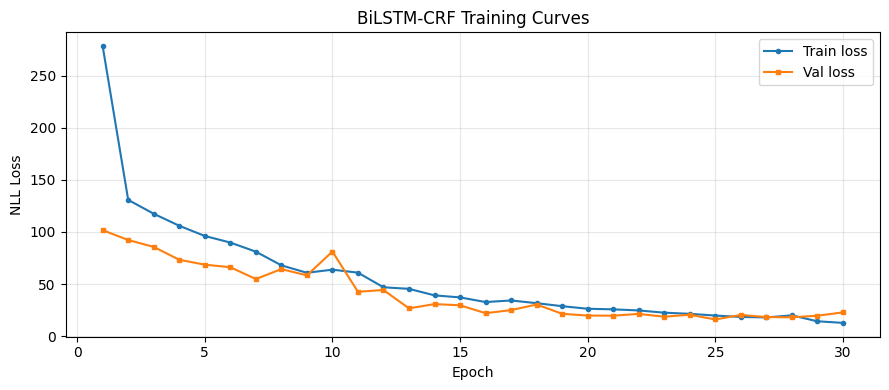

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], label='Train loss', marker='o', markersize=3)
ax.plot(epochs, history['val_loss'],   label='Val loss',   marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('NLL Loss')
ax.set_title('BiLSTM-CRF Training Curves')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

eval and predict

In [16]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()


@torch.no_grad()
def collect_predictions(model, loader, device, id2label, pad_label_id):
    """
    Run Viterbi decoding on loader and return sequence-level lists:
    - all_true: list[list[str]]  (one list of labels per sequence)
    - all_pred: list[list[str]]  (one list of predicted labels per sequence)
    PAD positions are excluded from the returned sequences.
    """
    all_true, all_pred = [], []
    for token_ids, char_ids, labels, mask in loader:
        token_ids = token_ids.to(device)
        char_ids  = char_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)

        pred_paths = model.predict(token_ids, char_ids, mask)  # list of lists
        seq_lens   = mask.long().sum(dim=1).tolist()

        for b, (path, slen) in enumerate(zip(pred_paths, seq_lens)):
            true_ids = labels[b, :slen].tolist()
            true_labels = [id2label.get(tid, 'O') for tid in true_ids]
            pred_labels = [id2label.get(pid, 'O') for pid in path]
            all_true.append(true_labels)
            all_pred.append(pred_labels)
    return all_true, all_pred


y_true, y_pred = collect_predictions(model, test_loader, DEVICE, id2label, PAD_LABEL_ID)

# Overall accuracy (token-level) — flatten sequences first
flat_true = [t for seq in y_true for t in seq]
flat_pred = [p for seq in y_pred for p in seq]
correct = sum(t == p for t, p in zip(flat_true, flat_pred))
print(f'Token accuracy : {correct / len(flat_true):.4f}  ({correct}/{len(flat_true)})')

Token accuracy : 0.8849  (6561/7414)


In [17]:
# Seqeval classification report (per-entity precision/recall/f1)
from seqeval.metrics import classification_report as seq_classification_report

print('Seqeval classification report (entity-level):')
print(seq_classification_report(y_true, y_pred))

Seqeval classification report (entity-level):
                     precision    recall  f1-score   support

       College Name       0.27      0.27      0.27        15
Companies worked at       0.52      0.21      0.30        57
             Degree       0.64      0.60      0.62        15
        Designation       0.61      0.33      0.43        60
      Email Address       0.71      0.71      0.71        24
    Graduation Year       0.83      0.42      0.56        12
           Location       0.00      0.00      0.00         4
               Name       0.91      0.88      0.90        34
             Skills       0.00      0.00      0.00        17
Years of Experience       1.00      0.17      0.29         6

          micro avg       0.60      0.40      0.48       244
          macro avg       0.55      0.36      0.41       244
       weighted avg       0.59      0.40      0.46       244



In [18]:
def bio_to_spans(tag_seq: list[str]) -> set[tuple]:
    """
    Convert a flat BIO tag sequence to a set of (start, end, label) spans.
    end is exclusive.
    """
    spans = set()
    current_label = None
    start = None
    for i, tag in enumerate(tag_seq):
        if tag.startswith('B-'):
            if current_label is not None:
                spans.add((start, i, current_label))
            current_label = tag[2:]
            start = i
        elif tag.startswith('I-'):
            # Mismatch → close current, open new (error-recovery)
            if current_label != tag[2:]:
                if current_label is not None:
                    spans.add((start, i, current_label))
                current_label = tag[2:]
                start = i
        else:   # O
            if current_label is not None:
                spans.add((start, i, current_label))
            current_label = None
            start = None
    if current_label is not None:
        spans.add((start, len(tag_seq), current_label))
    return spans


def span_metrics(true_tags: list[str], pred_tags: list[str]) -> dict:
    true_spans = bio_to_spans(true_tags)
    pred_spans = bio_to_spans(pred_tags)
    tp = len(true_spans & pred_spans)
    fp = len(pred_spans - true_spans)
    fn = len(true_spans - pred_spans)
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return {'precision': p, 'recall': r, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


# Use flattened sequences for span-level exact-match metrics
flat_true = [t for seq in y_true for t in seq]
flat_pred = [p for seq in y_pred for p in seq]

overall = span_metrics(flat_true, flat_pred)
print('Overall span-level metrics (exact match):')
for k, v in overall.items():
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')

# Per-entity span metrics
print('\nPer-entity span-level F1:')
print(f'{"Entity":<30} {"P":>7} {"R":>7} {"F1":>7}')
print('-' * 55)
for lbl in Entity_labels:
    true_lbl = [t if t.endswith(lbl) else 'O' for t in flat_true]
    pred_lbl = [p if p.endswith(lbl) else 'O' for p in flat_pred]
    m = span_metrics(true_lbl, pred_lbl)
    print(f'{lbl:<30} {m["precision"]:>7.3f} {m["recall"]:>7.3f} {m["f1"]:>7.3f}')

Overall span-level metrics (exact match):
  precision   : 0.5976
  recall      : 0.4016
  f1          : 0.4804
  tp          : 98
  fp          : 66
  fn          : 146

Per-entity span-level F1:
Entity                               P       R      F1
-------------------------------------------------------
Name                             0.708   0.694   0.701
Designation                      0.606   0.333   0.430
Companies worked at              0.522   0.211   0.300
Location                         0.000   0.000   0.000
Email Address                    0.708   0.708   0.708
College Name                     0.267   0.267   0.267
Degree                           0.643   0.600   0.621
Graduation Year                  0.833   0.417   0.556
Skills                           0.000   0.000   0.000
Years of Experience              1.000   0.167   0.286


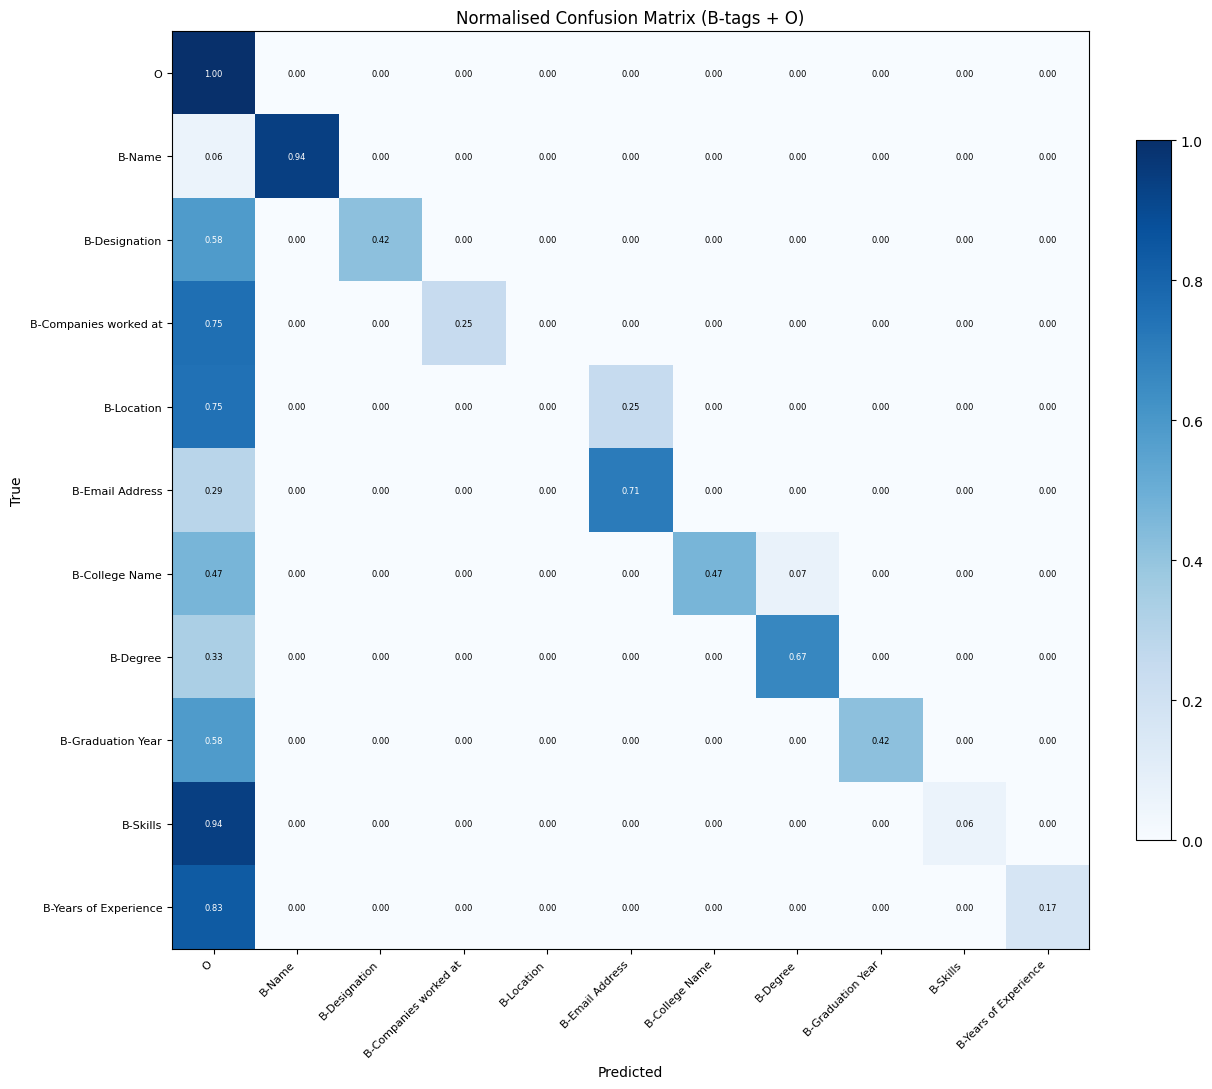

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors

# Flatten sequences for confusion matrix
flat_true = [t for seq in y_true for t in seq]
flat_pred = [p for seq in y_pred for p in seq]

# B-tag only for cleaner matrix
b_labels = ['O'] + [f'B-{l}' for l in Entity_labels]

y_true_b = [t if t in b_labels else 'O' for t in flat_true]
y_pred_b = [p if p in b_labels else 'O' for p in flat_pred]

cm = confusion_matrix(y_true_b, y_pred_b, labels=b_labels)

# Normalise by true counts (recall-style)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(len(b_labels)))
ax.set_yticks(range(len(b_labels)))
ax.set_xticklabels(b_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(b_labels, fontsize=8)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Normalised Confusion Matrix (B-tags + O)')

# Annotate cells
for i in range(len(b_labels)):
    for j in range(len(b_labels)):
        v = cm_norm[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=6, color='white' if v > 0.5 else 'black')

plt.tight_layout()
plt.show()


In [20]:
import re, unicodedata, spacy

nlp = spacy.load('en_core_web_sm')

# ── Replicate the preprocessing steps from Preprocessing.ipynb ──────

CHAR_PAD = '<CPAD>'
CHAR_UNK = '<CUNK>'
_TECH_TOKEN = re.compile(r'[+#]|\d|\.\w|^[A-Z]{1,5}$|^\.[a-z]+')
_NOISE_PATTERN = re.compile(r'^[^\w.#+]+$|^[\-–—]+$|^[•·▪●■◦○]+$')
Non_lemma_label = vocabs.get('Non_lemma_label', [])

def is_tech_token(t): return bool(_TECH_TOKEN.search(t))
def is_noise(t):      return bool(_NOISE_PATTERN.match(t)) or not t.strip()
def to_ascii(t):      return unicodedata.normalize('NFKD', t).encode('ascii','ignore').decode('ascii')
def case_fold(t):     return to_ascii(t).lower()
def strip_edges(t):
    if t.startswith('##'):
        return '##' + re.sub(r'^[^\w#]+|[^\w]+$', '', t[2:])
    return re.sub(r'^[^\w.#+]+|[^\w.#+]+$', '', t)
def lemmatize(t):
    if is_tech_token(t): return t
    doc = nlp(t)
    return doc[0].lemma_ if doc else t

def normalize_token(tok, apply_lemma=True):
    is_tech = is_tech_token(tok)
    tok = case_fold(tok)
    tok = strip_edges(tok)
    if is_noise(tok): return None
    if apply_lemma and not is_tech and len(tok) > 2:
        tok = lemmatize(tok)
    return tok or None

def word_tokenize(text):
    return [(m.group(), m.start(), m.end()) for m in re.finditer(r'\S+', text)]

def encode_token(tok, token2id, unk_id):
    return token2id.get(tok, unk_id)

def encode_chars_single(tok, char2id, max_char=20):
    pad = char2id.get(CHAR_PAD, 0)
    unk = char2id.get(CHAR_UNK, 1)
    ids = [char2id.get(c, unk) for c in tok[:max_char]]
    return ids + [pad] * (max_char - len(ids))


def predict_resume(text: str, model, token2id, char2id, id2label,
                   pad_id, unk_id, device, max_len=256, max_char=20) -> list[tuple]:
    """
    Given raw resume text, return list of (token, predicted_label) for entity tokens.
    """
    raw_tokens = word_tokenize(text)
    norm_tokens = []
    raw_kept    = []
    for raw_tok, _, _ in raw_tokens:
        norm = normalize_token(raw_tok)
        if norm is not None:
            norm_tokens.append(norm)
            raw_kept.append(raw_tok)

    # Truncate / pad to max_len
    tok_ids  = [encode_token(t, token2id, unk_id) for t in norm_tokens[:max_len]]
    char_ids = [encode_chars_single(t, char2id, max_char) for t in norm_tokens[:max_len]]
    real_len = len(tok_ids)

    pad_char = [char2id.get(CHAR_PAD, 0)] * max_char
    tok_ids  += [pad_id] * (max_len - real_len)
    char_ids += [pad_char] * (max_len - real_len)
    mask     = [True] * real_len + [False] * (max_len - real_len)

    t_tokens = torch.tensor([tok_ids],  dtype=torch.long).to(device)
    t_chars  = torch.tensor([char_ids], dtype=torch.long).to(device)
    t_mask   = torch.tensor([mask],     dtype=torch.bool).to(device)

    model.eval()
    with torch.no_grad():
        pred_paths = model.predict(t_tokens, t_chars, t_mask)

    path = pred_paths[0]  # (real_len,)
    results = []
    for raw_tok, tag_id in zip(raw_kept[:real_len], path):
        tag = id2label.get(tag_id, 'O')
        results.append((raw_tok, tag))
    return results


# ── Demo ─────────────────────────────────────────────────────────────
sample_resume = """
John Smith  |  john.smith@email.com  |  Bangalore, Karnataka

Senior Software Engineer with 7 years of experience in Python, Java, and AWS.
Graduated from IIT Bombay in 2016 with a Bachelor of Technology in Computer Science.

Experience
----------
Infosys Limited  (2018 – present)  — Lead Developer, Machine Learning Platform
Wipro Technologies  (2016 – 2018)  — Software Engineer

Skills: Python, Java, C++, AWS, Docker, Kubernetes, TensorFlow, SQL, Git
"""

predictions = predict_resume(
    sample_resume, model, token2id, char2id, id2label,
    PAD_ID, UNK_ID, DEVICE
)

print(f'{"Token":<30} {"Predicted Tag"}')
print('=' * 55)
for tok, tag in predictions:
    if tag != 'O':
        print(f'{tok:<30} {tag}')

Token                          Predicted Tag
John                           B-Name
Smith                          I-Name
john.smith@email.com           I-Name
7                              B-Years of Experience
years                          I-Years of Experience
2016                           B-Graduation Year
Developer,                     I-Skills
Machine                        I-Skills
Learning                       I-Skills
Platform                       I-Skills
Wipro                          I-Skills
Technologies                   I-Skills
(2016                          I-Skills
2018)                          I-Skills
Software                       I-Skills
Engineer                       I-Skills
Skills:                        I-Skills
Python,                        I-Skills
Java,                          I-Skills
C++,                           I-Skills
AWS,                           I-Skills
Docker,                        I-Skills
Kubernetes,                    I-Skills
Tensor